In [ ]:
import base64
import json
import os
from typing import List, Optional, Dict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
# Modern PyMuPDF (v1.28+) import
try:
    import pymupdf
    PDF_SUPPORT = True
    print("✅ PyMuPDF (v1.28+) loaded successfully.")
except ImportError:
    PDF_SUPPORT = False
    print("⚠️ PyMuPDF not installed. Run %pip install pymupdf in notebook.")
load_dotenv()
print("✅ Cell 1 initialized successfully.")



os.environ["OPENAI_API_KEY"]= os.getenv("OPENAI_API_KEY")

✅ PyMuPDF (v1.28+) loaded successfully.
✅ Cell 1 initialized successfully.


In [56]:
from typing import List, Optional, Dict, Literal
from pydantic import BaseModel, Field

# 1. Visual Markings Schema (None if no circled markings exist)
class VisualAnnotation(BaseModel):
    annotation_type: str = Field(description="e.g., 'Circled Number', 'Handwritten Checkmark'")
    target_text_or_number: str = Field(description="The exact text or number marked, e.g., '10'")
    bounding_box_location: Optional[str] = Field(description="Location in document")

# 2. Extracted Requirements Schema
class ExtractedDocumentRequirement(BaseModel):
    document_type: str = Field(description="e.g., 'Job Fitness Form', 'Doctor Prescription'")
    patient_name: Optional[str] = Field(description="Patient/Applicant Name if visible")
    required_test_name: str = Field(description="Extracted test name from document")
    required_sample_matrix: str = Field(description="Specimen required: 'Urine', 'Blood', 'Saliva', etc.")
    required_panel_count: Optional[int] = Field(description="Number of panels required (e.g., 10 for 10-Panel)")
    visual_annotations: Optional[List[VisualAnnotation]] = Field(
        default=None, 
        description="MUST BE null/None if no circled numbers or markings exist."
    )

# 3. Lab's Catalog Item Schema
class CatalogProduct(BaseModel):
    sku_id: str
    product_name: str
    sample_matrix: str
    panel_count: int
    price_inr: float
    description: str

# 4. Final Lab Availability & Operator Validation Report
class LabBookingReport(BaseModel):
    is_test_available_in_lab: bool = Field(description="True if matching test SKU exists in Lab's catalog")
    matched_catalog_product: Optional[CatalogProduct] = Field(default=None, description="The matching SKU details from lab catalog")
    
    # Operator validation fields
    operator_selected_sku: Optional[str] = Field(default="", description="SKU selected by caller/operator if provided")
    validation_status: Literal["PASSED", "HARD_VALIDATION_WARNING", "NOT_AVAILABLE_IN_LAB", "SEARCH_ONLY"]
    mismatch_reasons: List[str] = Field(default_factory=list)
    ai_recommendation_summary: str


In [57]:
# Lab Product Catalog Database Simulation
LAB_CATALOG: Dict[str, CatalogProduct] = {
    "SKU-DRUG-U10": CatalogProduct(
        sku_id="SKU-DRUG-U10",
        product_name="10-Panel Drug Screen Test (Urine)",
        sample_matrix="Urine",
        panel_count=10,
        price_inr=2500.0,
        description="Comprehensive 10-panel drug screening for corporate employment fitness."
    ),
    "SKU-DRUG-B05": CatalogProduct(
        sku_id="SKU-DRUG-B05",
        product_name="5-Panel Drug Screen Test (Blood)",
        sample_matrix="Blood",
        panel_count=5,
        price_inr=1800.0,
        description="Standard 5-panel drug test using blood sample."
    ),
    "SKU-DRUG-U05": CatalogProduct(
        sku_id="SKU-DRUG-U05",
        product_name="5-Panel Drug Screen Test (Urine)",
        sample_matrix="Urine",
        panel_count=5,
        price_inr=1200.0,
        description="Basic 5-panel urine drug test."
    ),
    "SKU-CBC-FULL": CatalogProduct(
        sku_id="SKU-CBC-FULL",
        product_name="Complete Blood Count (CBC)",
        sample_matrix="Blood",
        panel_count=20,
        price_inr=450.0,
        description="Standard full blood report."
    )
}

print(f"✅ Catalog loaded with {len(LAB_CATALOG)} products.")


✅ Catalog loaded with 4 products.


In [58]:
def load_document_as_base64_images(file_path: str) -> List[str]:
    ext = os.path.splitext(file_path)[1].lower()
    base64_images = []

    if ext == ".pdf":
        if not PDF_SUPPORT:
            raise ImportError("pymupdf module is required for PDF files. Run %pip install pymupdf.")
        doc = pymupdf.open(file_path)
        for page_index in range(min(len(doc), 3)):
            page = doc[page_index]
            pix = page.get_pixmap(dpi=150)
            img_bytes = pix.tobytes("png")
            base64_images.append(base64.b64encode(img_bytes).decode("utf-8"))
        doc.close()
    elif ext in [".jpg", ".jpeg", ".png", ".webp"]:
        with open(file_path, "rb") as f:
            base64_images.append(base64.b64encode(f.read()).decode("utf-8"))
    else:
        raise ValueError(f"Unsupported file format '{ext}'.")
        
    return base64_images


def extract_and_match_catalog(
    file_path: str, 
    catalog: Dict[str, CatalogProduct],
    additional_description: Optional[str] = None
) -> ExtractedDocumentRequirement:
    """
    Step 1: Extract requirements from PDF/Image (+ optional description).
    Returns visual_annotations=None if no circled markings exist.
    """
    base64_images = load_document_as_base64_images(file_path)
    
    llm = ChatOpenAI(model="gpt-4o", temperature=0.0)
    structured_llm = llm.with_structured_output(ExtractedDocumentRequirement)
    
    prompt = """
    You are an AI Diagnostic Specialist for Lab's.
    Analyze the provided lab document (PDF or Image).

    EXTRACTION INSTRUCTIONS:
    1. Extract the required test name, specimen matrix (Urine, Blood, etc.), and panel count.
    2. Check for VISUAL MARKINGS (e.g. circled numbers, handwritten checkmarks).
       - IMPORTANT: If there are NO visual markings or circled items in the document, set visual_annotations to null/None. Do NOT invent annotations.
    """
    
    if additional_description and additional_description.strip():
        prompt += f"\n\nOPTIONAL CUSTOMER / OPERATOR DESCRIPTION:\n\"{additional_description.strip()}\"\n"

    content_list = [{"type": "text", "text": prompt}]
    for base64_img in base64_images:
        content_list.append({
            "type": "image_url",
            "image_url": {"url": f"data:image/png;base64,{base64_img}"}
        })
    
    message = HumanMessage(content=content_list)
    extracted_req = structured_llm.invoke([message])
    return extracted_req


In [59]:
def search_catalog_and_validate(
    extracted_req: ExtractedDocumentRequirement,
    catalog: Dict[str, CatalogProduct],
    operator_selected_sku: Optional[str] = ""
) -> LabBookingReport:
    """
    1. Searches Lab's Catalog to check if extracted test is present in lab.
    2. Validates operator_selected_sku if caller provided one.
    """
    matched_product: Optional[CatalogProduct] = None
    
    # Search catalog for matching test (Sample Matrix + Panel Count / Test Name)
    for sku_id, product in catalog.items():
        same_sample = product.sample_matrix.lower() == extracted_req.required_sample_matrix.lower()
        same_panel = (extracted_req.required_panel_count is None or product.panel_count == extracted_req.required_panel_count)
        
        if same_sample and same_panel:
            matched_product = product
            break
            
    is_available = matched_product is not None
    mismatches = []
    
    # Case A: Requested test is NOT present in lab catalog
    if not is_available:
        return LabBookingReport(
            is_test_available_in_lab=False,
            matched_catalog_product=None,
            operator_selected_sku=operator_selected_sku,
            validation_status="NOT_AVAILABLE_IN_LAB",
            mismatch_reasons=[f"No catalog item found matching '{extracted_req.required_test_name}' ({extracted_req.required_sample_matrix} sample)."],
            ai_recommendation_summary=f"❌ TEST NOT OFFERED: Labs's catalog does not currently offer a {extracted_req.required_sample_matrix} {extracted_req.required_test_name}."
        )

    # Case B: Caller did not provide operator selection (Search Only mode)
    if not operator_selected_sku or operator_selected_sku.strip() == "":
        return LabBookingReport(
            is_test_available_in_lab=True,
            matched_catalog_product=matched_product,
            operator_selected_sku="",
            validation_status="SEARCH_ONLY",
            mismatch_reasons=[],
            ai_recommendation_summary=f"✅ TEST AVAILABLE IN LAB: Matched SKU '{matched_product.sku_id}' ({matched_product.product_name}). Price: ₹{matched_product.price_inr}"
        )

    # Case C: Operator selection provided -> Validate against matched catalog SKU
    selected_product = catalog.get(operator_selected_sku)
    if not selected_product:
        mismatches.append(f"Invalid SKU '{operator_selected_sku}' not found in catalog.")
    else:
        if selected_product.sku_id != matched_product.sku_id:
            mismatches.append(
                f"MISMATCH DETECTED: PDF requires '{matched_product.product_name}' ({matched_product.sku_id}), "
                f"but operator selected '{selected_product.product_name}' ({selected_product.sku_id})."
            )

    is_mismatch = len(mismatches) > 0
    return LabBookingReport(
        is_test_available_in_lab=True,
        matched_catalog_product=matched_product,
        operator_selected_sku=operator_selected_sku,
        validation_status="HARD_VALIDATION_WARNING" if is_mismatch else "PASSED",
        mismatch_reasons=mismatches,
        ai_recommendation_summary=(
            f"🚨 HARD VALIDATION WARNING! Operator selected wrong SKU '{operator_selected_sku}'. "
            f"System requires updating to matched SKU '{matched_product.sku_id}'."
            if is_mismatch else
            f"✅ PASSED: Operator selected SKU '{operator_selected_sku}' matches document requirement."
        )
    )


In [60]:
def analyze_lab_document(
    file_path: str,
    catalog: Dict[str, CatalogProduct],
    operator_selected_sku: Optional[str] = "",
    additional_description: Optional[str] = None
) -> LabBookingReport:
    """
    Main entry point called by client/operator.
    """
    print("======================================================================")
    print(f"📄 Processing File: {file_path}")
    if additional_description:
        print(f"📝 Customer/Operator Note: \"{additional_description}\"")
    if operator_selected_sku:
        print(f"👤 Operator Provided SKU: \"{operator_selected_sku}\"")
    else:
        print("🔍 Mode: Catalog Search & Lab Availability Check (No Operator SKU provided)")
    print("======================================================================\n")
    
    # 1. AI Vision & Text Extraction
    extracted_req = extract_and_match_catalog(file_path, catalog, additional_description)
    print("📌 [1. AI Document Extraction]:")
    print(json.dumps(extracted_req.model_dump(), indent=2))
    
    # 2. Search Lab Catalog & Validate Operator Selection
    report = search_catalog_and_validate(extracted_req, catalog, operator_selected_sku)
    print("\n🛡️ [2. Lab Availability & Validation Output]:")
    print(json.dumps(report.model_dump(), indent=2))
    
    return report


In [61]:
# Scenario A: Searching if test is available in lab (Without passing operator_selected_sku)
print("\n--- SCENARIO A: CATALOG SEARCH ONLY ---")
report_a = analyze_lab_document(
    file_path="/Users/vikaskesharvani/Pyhon-Projects/AgenticAiWorkFlow/sample.pdf",
    catalog=LAB_CATALOG,
    operator_selected_sku="" # Caller leaves SKU empty to check if test is present in lab
)




--- SCENARIO A: CATALOG SEARCH ONLY ---
📄 Processing File: /Users/vikaskesharvani/Pyhon-Projects/AgenticAiWorkFlow/sample.pdf
🔍 Mode: Catalog Search & Lab Availability Check (No Operator SKU provided)

📌 [1. AI Document Extraction]:
{
  "document_type": "ENT Consultation Note",
  "patient_name": "KESHARVANI VIKAS",
  "required_test_name": "CT SCAN-PNS PLAIN",
  "required_sample_matrix": "None",
  "required_panel_count": null,
  "visual_annotations": [
    {
      "annotation_type": "Circled Number",
      "target_text_or_number": "1",
      "bounding_box_location": "Top left of first medication"
    },
    {
      "annotation_type": "Circled Number",
      "target_text_or_number": "2",
      "bounding_box_location": "Top left of second medication"
    },
    {
      "annotation_type": "Circled Number",
      "target_text_or_number": "3",
      "bounding_box_location": "Top left of third medication"
    },
    {
      "annotation_type": "Handwritten Checkmark",
      "target_text_or_nu

In [62]:
# Scenario B: Operator passes incorrect SKU -> Hard Warning
print("\n--- SCENARIO B: OPERATOR ERROR VALIDATION ---")
report_b = analyze_lab_document(
    file_path="/Users/vikaskesharvani/Pyhon-Projects/AgenticAiWorkFlow/lab_test.jpeg",
    catalog=LAB_CATALOG,
    operator_selected_sku="SKU-DRUG-B05" # Operator selected Blood 5-panel by mistake
)



--- SCENARIO B: OPERATOR ERROR VALIDATION ---
📄 Processing File: /Users/vikaskesharvani/Pyhon-Projects/AgenticAiWorkFlow/lab_test.jpeg
👤 Operator Provided SKU: "SKU-DRUG-B05"

📌 [1. AI Document Extraction]:
{
  "document_type": "Lab Test Document",
  "patient_name": null,
  "required_test_name": "Drug Test",
  "required_sample_matrix": "Urine",
  "required_panel_count": 10,
  "visual_annotations": [
    {
      "annotation_type": "Circled Number",
      "target_text_or_number": "10",
      "bounding_box_location": "near 'Drug Test \u2013 All Panels'"
    }
  ]
}

🛡️ [2. Lab Availability & Validation Output]:
{
  "is_test_available_in_lab": true,
  "matched_catalog_product": {
    "sku_id": "SKU-DRUG-U10",
    "product_name": "10-Panel Drug Screen Test (Urine)",
    "sample_matrix": "Urine",
    "panel_count": 10,
    "price_inr": 2500.0,
    "description": "Comprehensive 10-panel drug screening for corporate employment fitness."
  },
  "operator_selected_sku": "SKU-DRUG-B05",
  "valid

### Part 3: LangGraph Code Implementation (Adding to Existing Code)
You can append this Cell 8 directly to your notebook without rewriting your previous code cells!


In [63]:
# ---------------------------------------------------------
# Cell 8: Single Human-in-the-Loop Node + Interrupt Middleware
# ---------------------------------------------------------
from typing import TypedDict, Optional, Dict, Any
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver  # Checkpointer middleware

# 1. Define State
class LabsState(TypedDict):
    file_path: str
    additional_description: Optional[str]
    extracted_req: Optional[Dict[str, Any]]
    matched_product: Optional[Dict[str, Any]]
    is_available: bool
    
    # Single Human Input Fields
    human_decision: Optional[str]        # "YES" or "NO"
    operator_selected_sku: Optional[str] # Human provides exact SKU if test was not found
    
    booking_status: str

# ---------------------------------------------------------
# 2. Define Nodes
# ---------------------------------------------------------

# NODE 1: AI Document Extraction & Catalog Match
def extract_and_match_node(state: LabsState) -> LabsState:
    print("\n🔹 [NODE 1] Extracting document & searching lab catalog...")
    req = extract_and_match_catalog(state["file_path"], LAB_CATALOG, state.get("additional_description"))
    report = search_catalog_and_validate(req, LAB_CATALOG, operator_selected_sku="")
    
    state["extracted_req"] = req.model_dump()
    state["is_available"] = report.is_test_available_in_lab
    if report.matched_catalog_product:
        state["matched_product"] = report.matched_catalog_product.model_dump()
        state["operator_selected_sku"] = report.matched_catalog_product.sku_id
    else:
        state["matched_product"] = None
        state["operator_selected_sku"] = ""
        
    print(f"   AI Catalog Match Found: {state['is_available']}")
    if not state['is_available']:
        print("   ⚠️ Test NOT found in catalog! Human operator must provide exact SKU.")
    return state


# NODE 2: SINGLE HUMAN-IN-THE-LOOP REVIEW NODE
def human_review_node(state: LabsState) -> LabsState:
    print("\n👤 [NODE 2: HUMAN-IN-THE-LOOP REVIEW]")
    if not state["is_available"]:
        print("   ⚠️ ALERT: Test was not found automatically.")
        print(f"   Human operator provided exact SKU: '{state.get('operator_selected_sku')}'")
    else:
        print(f"   AI Proposed SKU: '{state.get('operator_selected_sku')}'")
        
    print(f"   Human Decision: '{state.get('human_decision')}'")
    return state


# NODE 3: Final Verification & Booking Node
def validate_and_book_node(state: LabsState) -> LabsState:
    print("\n🎉 [NODE 3] Finalizing & Verification Check for Booking...")
    sku_to_book = state.get("operator_selected_sku")
    
    # Check if SKU exists in Lab's catalog
    if sku_to_book in LAB_CATALOG:
        product = LAB_CATALOG[sku_to_book]
        state["booking_status"] = f"BOOKING_CONFIRMED (SKU: {product.sku_id} - {product.product_name})"
        print(f"   ✅ SUCCESS: Booked test '{product.product_name}' for customer!")
    else:
        state["booking_status"] = f"BOOKING_FAILED (Invalid SKU '{sku_to_book}' provided by operator)"
        print(f"   ❌ REJECTED: {state['booking_status']}")
        
    return state


# ---------------------------------------------------------
# 3. Conditional Router
# ---------------------------------------------------------
def route_after_human_review(state: LabsState) -> str:
    decision = (state.get("human_decision") or "").upper()
    sku = (state.get("operator_selected_sku") or "").strip()
    
    # If Human approves (YES) AND an exact SKU is provided
    if decision == "YES" and len(sku) > 0:
        return "validate_and_book"
    else:
        state["booking_status"] = "BOOKING_CANCELLED_BY_HUMAN"
        print(f"\n❌ Workflow Ended: {state['booking_status']}")
        return END





In [64]:
# ---------------------------------------------------------
# 4. Build StateGraph & Attach Interrupt Middleware
# ---------------------------------------------------------
workflow = StateGraph(LabsState)

# Add Nodes
workflow.add_node("extract_and_match", extract_and_match_node)
workflow.add_node("human_review", human_review_node)
workflow.add_node("validate_and_book", validate_and_book_node)

# Set Entry Point & Edges
workflow.set_entry_point("extract_and_match")
workflow.add_edge("extract_and_match", "human_review")

workflow.add_conditional_edges(
    "human_review",
    route_after_human_review,
    {
        "validate_and_book": "validate_and_book",
        END: END
    }
)
workflow.add_edge("validate_and_book", END)

# 💡 ATTACH MIDDLEWARE & CHECKPOINTER FOR HUMAN-IN-THE-LOOP INTERRUPT
memory_saver = MemorySaver()
lab_app = workflow.compile(
    checkpointer=memory_saver,
    interrupt_before=["human_review"]  # 🛑 Automatically pauses BEFORE human review node!
)

print("✅ StateGraph compiled with LangGraph Interrupt Middleware!")

✅ StateGraph compiled with LangGraph Interrupt Middleware!


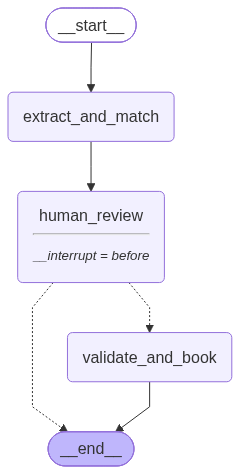

In [65]:
from IPython.display import Image, display
display(Image(lab_app.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
# ---------------------------------------------------------
# Cell 9: Interactive Execution with Terminal Input (input())
# ---------------------------------------------------------

thread_config = {"configurable": {"thread_id": "interactive_booking_session"}}

initial_state: LabsState = {
    "file_path": "/Users/vikaskesharvani/Pyhon-Projects/PathLabApp/lab_test.jpeg",
    "additional_description": "Needs 10-panel drug test",
    "extracted_req": None,
    "matched_product": None,
    "is_available": False,
    "human_decision": None,
    "operator_selected_sku": "",
    "booking_status": "STARTED"
}

if os.path.exists(initial_state["file_path"]):
    print("🚀 STEP 1: Running workflow up to Human Review...")
    
    # 1. Run graph up to the Interrupt Point
    lab_app.invoke(initial_state, config=thread_config)
    
    # 2. Get current state snapshot
    snapshot = lab_app.get_state(thread_config)
    current_state_values = snapshot.values
    
    print("\n=========================================================")
    print("⏸️ GRAPH PAUSED FOR HUMAN OPERATOR INPUT")
    print("=========================================================")
    
    # Display document & catalog status to operator
    if current_state_values.get("is_available"):
        matched_prod = current_state_values["matched_product"]
        print(f"✅ AI Found Catalog Match: {matched_prod['sku_id']} ({matched_prod['product_name']}) - Price: ₹{matched_prod['price_inr']}")
        default_sku = matched_prod['sku_id']
    else:
        print("⚠️ WARNING: AI did NOT find a direct match in Lab's catalog!")
        default_sku = ""

    # 3. TAKE INTERACTIVE INPUT FROM TERMINAL / NOTEBOOK
    print("\n👇 PLEASE ENTER YOUR OPERATOR INPUT:")
    
    # Take YES / NO decision from terminal
    human_yes_no = input("👉 Confirm booking? Enter YES or NO: ").strip().upper()
    
    # Take SKU input from terminal
    prompt_sku_msg = f"👉 Enter exact SKU code (Press ENTER to use '{default_sku}'): " if default_sku else "👉 Enter exact catalog SKU code (e.g. SKU-DRUG-U10): "
    entered_sku = input(prompt_sku_msg).strip()
    
    # If user presses Enter without typing, use default matched SKU
    final_sku = entered_sku if entered_sku else default_sku
    
    print("\n---------------------------------------------------------")
    print(f"📥 Received Input -> Decision: '{human_yes_no}', SKU: '{final_sku}'")
    print("---------------------------------------------------------\n")
    
    # 4. Update graph state with operator input
    lab_app.update_state(
        thread_config,
        {
            "human_decision": human_yes_no,
            "operator_selected_sku": final_sku
        }
    )
    
    # 5. Resume execution
    print("▶️ Resuming workflow with your terminal input...")
    final_output = lab_app.invoke(None, config=thread_config)
    
    print("\n🏁 FINAL RESULT:")
    print("Booking Status:", final_output["booking_status"])

else:
    print(f"⚠️ File '{initial_state['file_path']}' not found.")


🚀 STEP 1: Running workflow up to Human Review...

🔹 [NODE 1] Extracting document & searching lab catalog...
   AI Catalog Match Found: True

⏸️ GRAPH PAUSED FOR HUMAN OPERATOR INPUT
✅ AI Found Catalog Match: SKU-DRUG-U10 (10-Panel Drug Screen Test (Urine)) - Price: ₹2500.0

👇 PLEASE ENTER YOUR OPERATOR INPUT:

---------------------------------------------------------
📥 Received Input -> Decision: 'NO', SKU: 'No'
---------------------------------------------------------

▶️ Resuming workflow with your terminal input...

👤 [NODE 2: HUMAN-IN-THE-LOOP REVIEW]
   AI Proposed SKU: 'No'
   Human Decision: 'NO'

❌ Workflow Ended: BOOKING_CANCELLED_BY_HUMAN

🏁 FINAL RESULT:
Booking Status: STARTED
